Training BiRNN...

Epoch 10/50, Loss: 0.00538
Epoch 20/50, Loss: 0.00210
Epoch 30/50, Loss: 0.00208
Epoch 40/50, Loss: 0.00207
Epoch 50/50, Loss: 0.00236

Training Feedforward NN...

Epoch 10/50, Loss: 0.00502
Epoch 20/50, Loss: 0.00305
Epoch 30/50, Loss: 0.00246
Epoch 40/50, Loss: 0.00265
Epoch 50/50, Loss: 0.00247

Model Comparison
BiRNN MSE: 1711.039
FFNN MSE: 1477.059


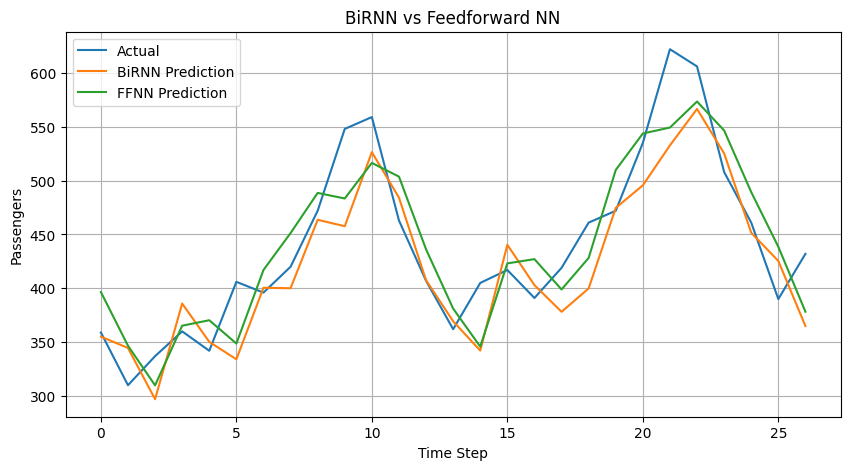

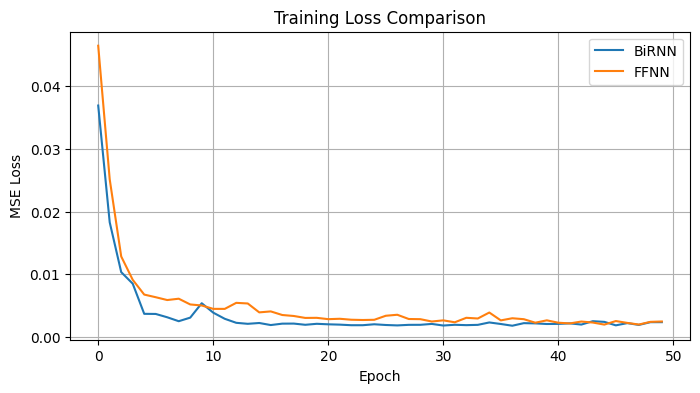

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/monthly-airline-passengers.csv"

df = pd.read_csv(url, usecols=[1])
data = df.values.astype("float32")

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

SEQ_LENGTH = 10

X = np.array([
    data_scaled[i:i+SEQ_LENGTH]
    for i in range(len(data_scaled) - SEQ_LENGTH)
])

y = np.array([
    data_scaled[i+SEQ_LENGTH]
    for i in range(len(data_scaled) - SEQ_LENGTH)
])

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)

X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=16,
    shuffle=True
)

class BiRNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class FeedforwardNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(10, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(self.relu(self.fc1(x)))

def train_model(model, loader, epochs=50):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    losses = []

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for seqs, targets in loader:

            optimizer.zero_grad()

            outputs = model(seqs)

            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1}/{epochs}, "
                f"Loss: {avg_loss:.5f}"
            )

    return losses

def predict(model, X):
    model.eval()

    with torch.no_grad():
        return model(X).numpy()

print("Training BiRNN...\n")

birnn = BiRNN()
loss_birnn = train_model(birnn, train_loader)

print("\nTraining Feedforward NN...\n")

ffnn = FeedforwardNN()
loss_ffnn = train_model(ffnn, train_loader)

pred_birnn = predict(birnn, X_test_tensor)
pred_ffnn = predict(ffnn, X_test_tensor)

pred_birnn_inv = scaler.inverse_transform(pred_birnn)
pred_ffnn_inv = scaler.inverse_transform(pred_ffnn)
y_test_inv = scaler.inverse_transform(y_test)

mse_birnn = mean_squared_error(y_test_inv, pred_birnn_inv)
mse_ffnn = mean_squared_error(y_test_inv, pred_ffnn_inv)

print("\nModel Comparison")
print(f"BiRNN MSE: {mse_birnn:.3f}")
print(f"FFNN MSE: {mse_ffnn:.3f}")

plt.figure(figsize=(10, 5))

plt.plot(y_test_inv, label="Actual")
plt.plot(pred_birnn_inv, label="BiRNN Prediction")
plt.plot(pred_ffnn_inv, label="FFNN Prediction")

plt.title("BiRNN vs Feedforward NN")
plt.xlabel("Time Step")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))

plt.plot(loss_birnn, label="BiRNN")
plt.plot(loss_ffnn, label="FFNN")

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()